<a href="https://colab.research.google.com/github/Tanish-k08/CM23021-Pattern_Recognition/blob/main/CM23021_PR_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving usps.h5 to usps.h5


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
file_name = "usps.h5"

data = h5py.File(file_name, 'r')

print(data.keys())

<KeysViewHDF5 ['test', 'train']>


In [ ]:
X_train = np.array(data['train']['data'])
y_train = np.array(data['train']['target'])
X_test = np.array(data['test']['data'])
y_test = np.array(data['test']['target'])
print("Training Data:",X_train.shape)
print("Training Labels:",y_train.shape)
print("Testing Data:",X_test.shape)
print("Testing Labels:",y_test.shape)

Training Data: (7291, 256)
Training Labels: (7291,)
Testing Data: (2007, 256)
Testing Labels: (2007,)


In [ ]:
print(X_train[0].shape)
X_train = X_train.reshape(-1,16,16)
X_test = X_test.reshape(-1,16,16)

(256,)


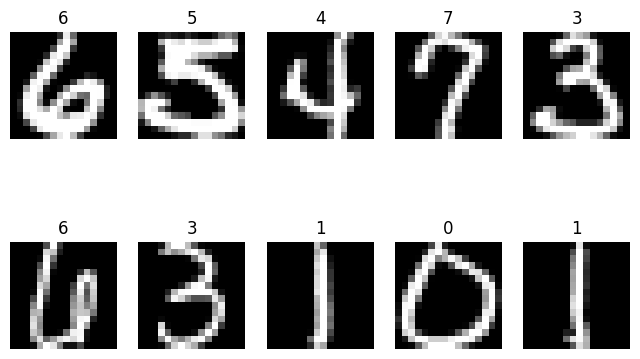

In [ ]:
plt.figure(figsize=(8,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(
        X_train[i],
        cmap='gray'
    )
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
!pip install scikit-image
from skimage.feature import hog
def extract_hog(images):
    features=[]
    for img in images:
        feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(4,4),
            cells_per_block=(2,2)
        )
        features.append(feature)
    return np.array(features)
X_train_hog = extract_hog(X_train)
X_test_hog = extract_hog(X_test)
print(X_train_hog.shape)

(7291, 324)


In [ ]:
svm = SVC(kernel='rbf')
svm.fit(
    X_train_hog,
    y_train
)
svm_pred = svm.predict(X_test_hog)
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)
print("SVM Accuracy:",svm_accuracy)

SVM Accuracy: 0.9621325361235675


In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=5
)
knn.fit(
    X_train_hog,
    y_train
)
knn_pred = knn.predict(X_test_hog)
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)
print("KNN Accuracy:",knn_accuracy)

KNN Accuracy: 0.9446935724962631


In [ ]:
results = pd.DataFrame({
"Algorithm":["SVM","KNN"],
"Accuracy":[
    svm_accuracy,
    knn_accuracy
]
})
results

,Algorithm,Accuracy
0,SVM,0.962133
1,KNN,0.944694
